# T13 · Learning the update rule

So far the networks in this course learned a function of a coordinate:
a temperature at a height, a potential at a radius. Here the network learns
a *time step*. It sees pairs of states one interval apart, u(t) and u(t+dt),
and has to learn the map

$$u(t+dt) = F\big(u(t)\big).$$

Once learned, the map is applied to its own output again and again. A small
error per step becomes a large error after a thousand steps, and the way it
grows depends on the structure of the model. That is the subject of this
notebook: what physical structure in a stepper buys on long rollouts.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

torch.set_num_threads(2)
from physprior.dynamics import systems as S, steppers as ST, train as TR, metrics as M
from physprior.dynamics import pdes as PD
from physprior.dynamics.figures import ARM_COLOR, ARM_LABEL

torch 2.11.0


## 1 · The pendulum, four ways

The pendulum $\ddot q = -\sin q$ conserves $H = p^2/2 - \cos q$. Training
data are 16 trajectories of 200 steps with $dt = 0.1$, from energies below the
separatrix. We compare four steppers with the same network size and the same
number of gradient steps (400 here, with a learning rate picked for a short
run; the study uses 1000 steps and a tuned rate):

- **direct**: $u' = \mathrm{NN}(u)$. The network has to output the next state,
  which is almost the current state, so it must learn the identity map to the
  accuracy of one step.
- **residual**: $u' = u + dt\,\mathrm{NN}(u)$. The identity is built in; the
  network learns the increment.
- **HNN (RK4)**: a scalar network $H_\theta(q,p)$; the vector field is
  $(\partial H/\partial p, -\partial H/\partial q)$ (Greydanus et al. 2019),
  integrated with RK4.
- **HNN (leapfrog)**: $H = T_\theta(p) + V_\theta(q)$ and a leapfrog update. The
  leapfrog map is symplectic for any $T$ and $V$, so the rollout conserves a
  nearby energy exactly (Chen et al. 2020).

In [2]:
sys = S.get_system("pendulum")
data = S.make_data(sys, n_traj=16, seed=11, n_test=8, n_val=2)
print("train", data.train.shape, "test", data.test.shape)

arms = ["direct", "residual", "hnn", "hnn_leapfrog"]
models, info = {}, {}
for arm in arms:
    m = ST.build_ode(arm, sys, data)
    info[arm] = TR.train(m, data.train, data.std, TR.TrainOptions(steps=400, lr=1e-2), seed=11)
    models[arm] = m
    print(f"{arm:13s} params {ST.n_params(m):5d}  final loss {info[arm]['final_loss']:.2e}"
          f"  {info[arm]['seconds']:.0f} s")

train (16, 201, 2) test (8, 1001, 2)


direct        params  4482  final loss 5.84e-05  0 s


residual      params  4482  final loss 4.40e-06  0 s


hnn           params  4417  final loss 3.88e-07  1 s


hnn_leapfrog  params  8706  final loss 1.05e-07  1 s


Each model is now rolled out for 1000 steps from the test initial states, five
times longer than any training trajectory. The rollout error is in training
standard deviations; the energy error is $|H(t) - H(0)|$ divided by the energy
above the bottom of the well.

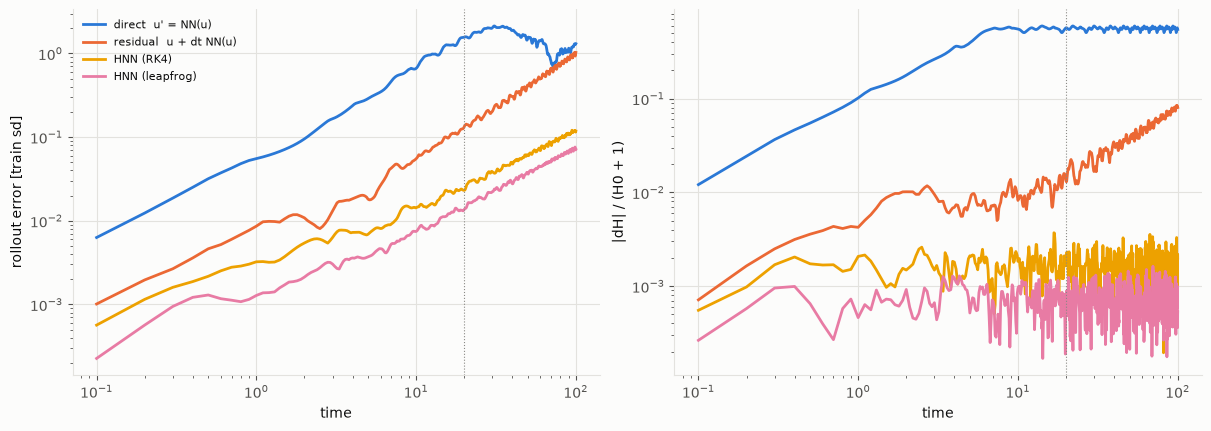

In [3]:
n = sys.test_steps
t = np.arange(n + 1) * sys.dt
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for arm in arms:
    pred = M.rollout(models[arm], data.test[:, 0], n, data.mean, data.std)
    err = np.median(M.error_curve(pred, data.test, data.std), axis=0)
    dH = np.median(M.invariant_drift(pred, S.pendulum_H, "H"), axis=0)
    ax[0].plot(t[1:], err[1:], color=ARM_COLOR[arm], label=ARM_LABEL[arm])
    ax[1].plot(t[1:], dH[1:], color=ARM_COLOR[arm], label=ARM_LABEL[arm])
for a, lab in zip(ax, ("rollout error [train sd]", "|dH| / (H0 + 1)")):
    a.set_xscale("log"); a.set_yscale("log"); a.set_xlabel("time"); a.set_ylabel(lab)
    a.axvline(sys.train_steps * sys.dt, color=P.INK_MUTED, ls=":", lw=0.8)
ax[0].legend(fontsize=8)
plt.show()

Things to look for. The direct stepper's error is large from the first step:
its one-step error is set by how well a network reproduces the identity. The
residual stepper starts better, and its energy error grows with time. The
leapfrog HNN's energy error stays at roughly the level it starts at, because
the map is symplectic; its *position* error still grows, because a small
error in the learned frequency accumulates as a phase error. Conserving
energy and predicting the trajectory are different things.

The phase portraits show the same thing: a drifting orbit spirals, a
symplectic one stays on a closed curve.

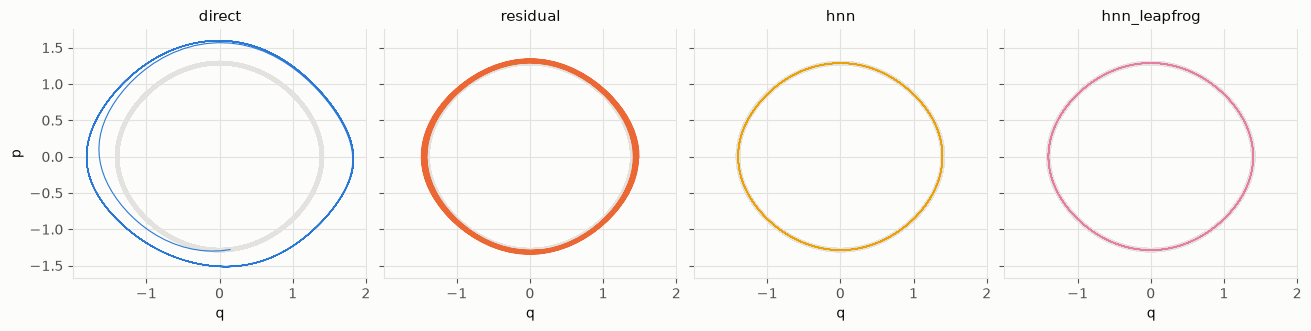

In [4]:
fig, axes = plt.subplots(1, len(arms), figsize=(13, 3.2), sharex=True, sharey=True)
for a, arm in zip(axes, arms):
    pred = M.rollout(models[arm], data.test[:1, 0], n, data.mean, data.std)[0]
    a.plot(data.test[0, :, 0], data.test[0, :, 1], color=P.GRID, lw=3)
    a.plot(pred[:, 0], pred[:, 1], color=ARM_COLOR[arm], lw=0.8)
    a.set_title(arm); a.set_xlabel("q")
axes[0].set_ylabel("p")
plt.show()

## 2 · Chaos: how long does a learned Lorenz model stay right?

Lorenz-63 is chaotic: two trajectories that start $\delta$ apart separate like
$\delta\,e^{\lambda_1 t}$ with $\lambda_1 \approx 0.906$. Any one-step
error, however small, is amplified the same way. The natural unit of
prediction time is therefore the Lyapunov time $1/\lambda_1$. The valid
prediction time is the time until the normalised error first exceeds 0.4
(Pathak et al. 2018).

We train a residual stepper and a closure stepper, which is given the linear
part of the equations and learns only the two products $xz$ and $xy$.

residual  one-step 2.83e-03   valid time median 1.34 Lyapunov times


node      one-step 3.03e-03   valid time median 1.30 Lyapunov times


closure   one-step 5.63e-03   valid time median 0.58 Lyapunov times


oracle    one-step 4.69e-07   valid time median 12.01 Lyapunov times


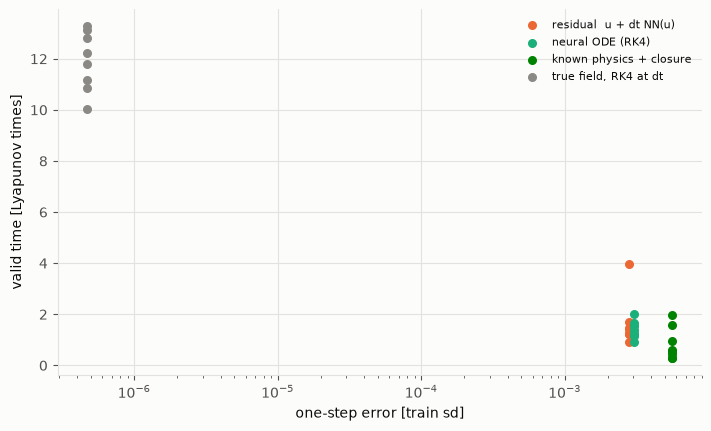

In [5]:
lz = S.get_system("lorenz")
ldata = S.make_data(lz, n_traj=16, seed=11, n_test=8, n_val=2)
lmodels = {}
for arm in ("residual", "node", "closure"):
    m = ST.build_ode(arm, lz, ldata)
    TR.train(m, ldata.train, ldata.std, TR.TrainOptions(steps=300, lr=1e-2), seed=11)
    lmodels[arm] = m
lmodels["oracle"] = ST.build_ode("oracle", lz, ldata)

n = 1500
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, (arm, m) in enumerate(lmodels.items()):
    pred = M.rollout(m, ldata.test[:, 0], n, ldata.mean, ldata.std)
    curve = M.error_curve(pred, ldata.test[:, : n + 1], ldata.std)
    vpt = M.valid_steps(curve, M.LORENZ_THR) * lz.dt * S.LORENZ_LAMBDA1
    one = M.onestep_error(m, ldata.test, ldata.std)
    ax.scatter(np.full(len(vpt), one), vpt, color=ARM_COLOR[arm], label=ARM_LABEL[arm], s=30)
    print(f"{arm:9s} one-step {one:.2e}   valid time median {np.median(vpt):.2f} Lyapunov times")
ax.set_xscale("log"); ax.set_xlabel("one-step error [train sd]")
ax.set_ylabel("valid time [Lyapunov times]"); ax.legend(fontsize=8)
plt.show()

Each point is one test initial state. The valid time grows roughly with the
logarithm of the inverse one-step error: dividing the one-step error by
$e$ buys about one more Lyapunov time. The reference row is the true vector
field with one RK4 step of size $dt$; its error per step is the integrator's
own, so it sets the ceiling for any stepper at this $dt$.

## 3 · Burgers: a local stepper and a dense one

On a grid, the update of one point depends only on its neighbours; a
finite-difference stencil is local, and it is the same everywhere. A
convolution with a small kernel and circular padding has exactly those two
properties. A dense network over the whole grid has neither: it has to learn
from data that the rule does not depend on position.

Viscous Burgers, $u_t + u u_x = \nu u_{xx}$ with $\nu = 0.03$, forms steep
fronts that are about one cell wide on this 64-point grid.

conv   params   1281  final loss 4.09e-05


dense  params  98880  final loss 1.57e-04


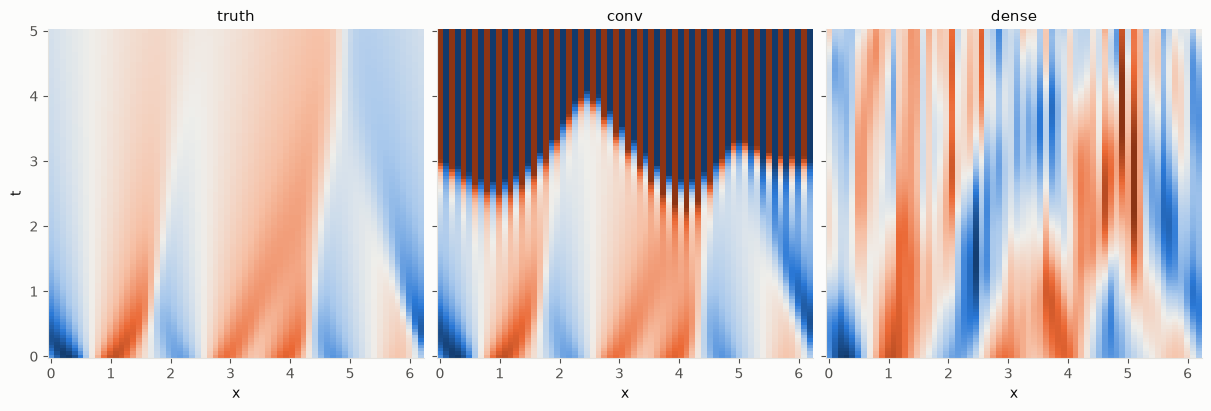

In [6]:
bd = PD.make_pde_data("burgers", n_traj=16, seed=11, n_test=4, n_val=2)
bs = PD.PDES["burgers"]
pm = {
    "conv": ST.ConvStepper(PD.N_GRID, bs.dt, bd.mean, bd.std, bd.dstd),
    "dense": ST.DenseStepper(PD.N_GRID, bs.dt, bd.mean, bd.std, bd.dstd),
}
for arm, m in pm.items():
    r = TR.train(m, bd.train, bd.std, TR.TrainOptions(steps=300, batch=32, lr=1e-2), seed=11)
    print(f"{arm:6s} params {ST.n_params(m):6d}  final loss {r['final_loss']:.2e}")

n = bs.test_steps
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
t = np.arange(n + 1) * bs.dt
truth = bd.test[0]
lim = np.abs(truth).max()
panels = [("truth", truth)] + [
    (arm, M.rollout(m, bd.test[:1, 0], n, bd.mean, bd.std)[0]) for arm, m in pm.items()
]
for a, (lab, u) in zip(axes, panels):
    a.pcolormesh(PD.grid(), t, np.where(np.isfinite(u), u, np.nan),
                 cmap=P._diverging_cmap(), vmin=-lim, vmax=lim, shading="auto")
    a.set_title(lab); a.set_xlabel("x"); a.grid(False)
axes[0].set_ylabel("t")
plt.show()

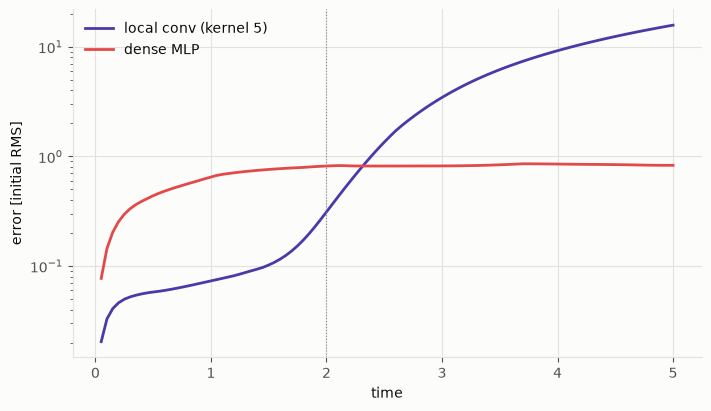

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
rms0 = bd.test[:, :1].std(axis=-1, keepdims=True)
for arm, m in pm.items():
    pred = M.rollout(m, bd.test[:, 0], n, bd.mean, bd.std)
    ax.plot(t[1:], np.median(M.error_curve(pred, bd.test, rms0), axis=0)[1:],
            color=ARM_COLOR[arm], label=ARM_LABEL[arm])
ax.axvline(bs.train_steps * bs.dt, color=P.INK_MUTED, ls=":", lw=0.8)
ax.set_yscale("log"); ax.set_xlabel("time"); ax.set_ylabel("error [initial RMS]")
ax.legend(); plt.show()

## 4 · What the full study measured

The study repeats all of this with tuned learning rates, three reporting
seeds, four ODE systems and three PDEs, one-step and unrolled training
losses, and a sweep over the number of training trajectories. Its
expectations were written down, with what would refute each, before the
reported runs. The verdicts are read from the results files here.

In [8]:
from physprior.io import load_json
try:
    ver = load_json("dynamics", "expectations")
    for k, v in ver.items():
        print(k, v["verdict"])
except FileNotFoundError:
    print("run physprior.dynamics.study.run() to produce results/dynamics/")

E1 supported
E2 supported
E3 supported
E4 refuted
E5 refuted
E6 refuted
E7 refuted
E8 supported
E9 supported


The page `docs/dynamics/README.md` has the tables and figures behind each
verdict.

References: Greydanus, Dzamba & Yosinski, *Hamiltonian Neural Networks*,
NeurIPS 2019; Chen, Zhang, Arjovsky & Bottou, *Symplectic Recurrent Neural
Networks*, ICLR 2020; Pathak et al., Phys. Rev. Lett. 120, 024102 (2018);
Yin et al., *APHYNITY*, J. Stat. Mech. (2021) 124012.